# DEVP 209 Section 5

In this lab, we will be using Python and Pandas to understand Bayes' rule of conditional probability and also apply conditionality to use indicator variables

## Imports

In [1]:
import pandas as pd # We can give aliases to packages; can call it whatever I want to save typing
import datetime # This allows me to use dates
import numpy as np #This is the second most popular package after Pandas most likely
import statsmodels.api as sm
import  matplotlib.pyplot as plt

### Practicing Bayes' rule

First, let us see something about how a dataset is represented

In [2]:
removals = pd.read_csv('removals.csv')
print(len(removals))
removals.head()

144176


,Departed Date,Departure Country,Gender,Birth Country,Citizenship Country,Birth Year,Entry Date
0,2025-01-01,MEXICO,Male,MEXICO,MEXICO,1998,12/31/2024
1,2025-01-01,MEXICO,Male,MEXICO,MEXICO,1995,12/29/2024
2,2025-01-01,MEXICO,Male,MEXICO,MEXICO,2006,12/21/2024
3,2025-01-01,MEXICO,Male,MEXICO,MEXICO,1997,12/30/2024
4,2025-01-01,MEXICO,Male,MEXICO,MEXICO,2014,12/31/2024


I have a dataset of removals from our ICE data work (https://deportationdata.org/data/ice.html)
Let us see what happens when I do some of the filtering in Pandas that we have already learned

In [3]:
(removals['Departure Country'] == 'MEXICO')

0          True
1          True
2          True
3          True
4          True
          ...  
144171     True
144172     True
144173     True
144174    False
144175    False
Name: Departure Country, Length: 144176, dtype: bool

So it seems that if I do a check for if the `'Departure Country'` column is equal to the value of `'MEXICO'` then I get a list of `True` and `False` values. This is simply checking every single row in this column and letting us know whether or not our check is right or wrong. Something interesting though happens when I do the following

IMPORTANT TO NOTE: `True` when used in math is the same as 1 and `False` is the same as 0

In [4]:
(removals['Departure Country'] == 'MEXICO').sum()

72691

Here I see that there are 72,691 different removals for people from Mexico. Above, I can also see that there 144,176 different rows. This means that I can simply do a sum here and divide by all of the rows to see the probability of being a Mexican out of the people that are removed. This is shown below

In [5]:
probabilityOfMexicanArrest = (removals['Departure Country'] == 'MEXICO').sum()/len(removals)
print(probabilityOfMexicanArrest)

0.5041823881922095


Another way we can do this is simply taking the mean value. This can be interpreted simply since we have a bunch of `True` values that equal 1, then we are finding the average number of 1s which is the same as the probability

In [6]:
probabilityOfMexicanArrest2 = (removals['Departure Country'] == 'MEXICO').mean()
print(probabilityOfMexicanArrest2)

0.5041823881922095


This is our first real introduction on how we can use filtering to find probabilities in data.

Below we are going to go through some exercises to practice using the above information to see Bayes' rule using a new set of data: detentions.

It is so long that it actually was split into two lol so we need to combine them as below

In [7]:
detentions1 = pd.read_csv('detentions1.csv')
detentions2 = pd.read_csv('detentions2.csv')
detentions = pd.concat([detentions1,detentions2],axis=0)
detentions.head()

,Detention Release Reason,Stay Book Out Date,Religion,Gender,Marital Status,Birth Year,Ethnicity,Felon,Final Charge,Departed Date,Departure Country,Initial Bond Set Amount,Citizenship Country
0,Removed,7/4/2024,NaN,Male,Single,1991,NaN,NaN,3 Other Immigration Violator,7/4/2024,MEXICO,NaN,MEXICO
1,Removed,9/9/2023,NaN,Female,Single,1993,NaN,NaN,3 Other Immigration Violator,9/9/2023,MEXICO,NaN,MEXICO
2,Transferred,9/9/2023,NaN,Female,Single,1993,NaN,NaN,3 Other Immigration Violator,9/9/2023,MEXICO,NaN,MEXICO
3,Removed,6/25/2024,NaN,Male,Single,2000,NaN,NaN,3 Other Immigration Violator,6/25/2024,COLOMBIA,NaN,COLOMBIA
4,Transferred,9/4/2024,NaN,Female,Single,1968,Not of Hispanic Origin,Not an Aggravated Felon,1 Convicted Criminal,9/5/2024,GUYANA,NaN,GUYANA


Let us now try to answer some questions about our dataset to understand the population
* What is the sample space of Departure Countries?
* What is the Probability of being 'Removed' for the Detention Release Reason?
* What is the number of rows that represent the Union of people from COLOMBIA and those that are Tranferred?
* What is the number of rows that represent the Intersection of People born after 2000 that are Female?
* What is the complement to the above question?

Now we will try to answer some questions about probability and use Bayes' rule; first look at the given example

In [8]:
# Probability male
P_A = (detentions['Departure Country'] == 'MEXICO').mean()
P_B = (detentions['Gender'] == 'Male').mean()

# Probability male and mexican
P_AB = ((detentions['Departure Country'] == 'MEXICO') & (detentions['Gender'] == 'Male')).sum()/len(detentions)

# Likelihood: P(MEXICO | MALE)
conditional_AB = P_AB *P_A/ P_B
# Likelihood: P(Male | MEXICO)
conditional_BA = P_AB *P_B/ P_A

print(conditional_AB)
print(conditional_BA)


0.044286159964245425
0.8256553591236238


This means that 44% of Male removals are from Mexico and 82% of Mexican removals are Male!

Let us now try to figure out some conditional values in our dataset
* What is probability of a female detained if they are younger than 30?
* What is the probability of being a Venezuelan detained if they are Catholic?
* What is the probability of being Catholic if they are Venezuelan?
* What is the odds that they are removed if they have Felon value of '`Drugs`'?
* What is chances of being Removed if the person is Colombian?
* What is the chances of being Removed if the person is Colombian and has an Initia Bond Set Amount that is not Nan (hint: you need to use `~pd.isnull(detentions['Initial Bond Set Amount'])`)

## Challenge Section: Regressing using indicator variables

I am now trying to see if there is a trend between gender concentration of detentions and likelihood of removals.
First, for each country, I am finding the percentage of the population that is male and then the percentage of the population that is removed
    

### Step 1: Create a scatter plot that is not a time series

First step is creating a dataframe that simply relates two numerical values that ~might~ be related

In [9]:
# Percent Male per Citizenship Country
male_pct = (
    detentions.groupby("Citizenship Country")["Gender"]
      .apply(lambda x: (x == "Male").mean() * 100)
      .reset_index(name="Percent_Male")
)

# Percent 'Removed' per Citizenship Country
removed_pct = (
    detentions.groupby("Citizenship Country")["Detention Release Reason"]
      .apply(lambda x: (x == "Removed").mean() * 100)
      .reset_index(name="Percent_Removed")
)

# Merge results
country_stats = pd.merge(male_pct, removed_pct, on="Citizenship Country")
country_stats.head()

,Citizenship Country,Percent_Male,Percent_Removed
0,AFGHANISTAN,92.027864,2.902477
1,ALBANIA,91.343284,11.044776
2,ALGERIA,96.000000,14.857143
3,ANGOLA,77.937267,10.101010
4,ANGUILLA,100.000000,0.000000


### Step 2: Create a scatter plot

I decided to label some countries, but this is not necessary. Last week, you learned to make scatter plots and add labels

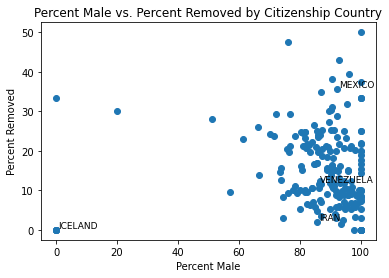

In [10]:
plt.figure()
plt.scatter(country_stats["Percent_Male"], country_stats["Percent_Removed"])
plt.xlabel("Percent Male")
plt.ylabel("Percent Removed")
plt.title("Percent Male vs. Percent Removed by Citizenship Country")

# Add labels for selected countries
highlight_countries = ["MEXICO", "VENEZUELA", "IRAN", "ICELAND", "CHINA"]

for _, row in country_stats[country_stats["Citizenship Country"].isin(highlight_countries)].iterrows():
    plt.text(row["Percent_Male"]+0.5,  # shift slightly to the right
             row["Percent_Removed"]+0.5,  # shift slightly upward
             row["Citizenship Country"],
             fontsize=9, color="black")

plt.show()

### Step 3: Add an indicator variable

As we learned in class, an indicator variable is a column of 1s and 0s. I am making an indicator variable for if a country is in Europe

In [11]:
# I Googled these
european_countries = ['GERMANY', 'FRANCE', 'ITALY', 'SPAIN', 'PORTUGAL', 'POLAND', 'NETHERLANDS',
                      'BELGIUM', 'SWEDEN', 'NORWAY', 'DENMARK', 'FINLAND', 'ICELAND', 'IRELAND',
                      'GREECE', 'AUSTRIA', 'SWITZERLAND', 'HUNGARY', 'CZECH REPUBLIC', 'SLOVAKIA',
                      'SLOVENIA', 'CROATIA', 'SERBIA', 'ROMANIA', 'BULGARIA', 'ESTONIA', 'LATVIA', 'LITHUANIA', 'UKRAINE', 'RUSSIA', 'TURKEY']

country_stats['European'] = (country_stats['Citizenship Country'].isin(european_countries)).astype(int)
country_stats.head()


,Citizenship Country,Percent_Male,Percent_Removed,European
0,AFGHANISTAN,92.027864,2.902477,0
1,ALBANIA,91.343284,11.044776,0
2,ALGERIA,96.000000,14.857143,0
3,ANGOLA,77.937267,10.101010,0
4,ANGUILLA,100.000000,0.000000,0


### Step 4: Regress on the indicator variable

In [12]:
# Define regression: Percent_Removed ~ Percent_Male + European
X = country_stats[["Percent_Male", "European"]]
X = sm.add_constant(X)
y = country_stats["Percent_Removed"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        Percent_Removed   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     12.80
Date:                Tue, 30 Sep 2025   Prob (F-statistic):           5.94e-06
Time:                        23:11:17   Log-Likelihood:                -729.85
No. Observations:                 200   AIC:                             1466.
Df Residuals:                     197   BIC:                             1476.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.7347      3.272      3.281   

### Challenge 1: Interpret the indicator variable

### Challenge 2: Add an indicator variable on the slope